In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:

# Create Sample Dataset

np.random.seed(42)

years = np.arange(2005, 2026)
vehicle_types = ['Car', 'SUV', 'Truck']
seasons = ['Q1', 'Q2', 'Q3', 'Q4']

data = []

for year in years:
    recession = 'Yes' if year in [2008, 2009, 2020] else 'No'
    gdp = round(np.random.uniform(10000, 20000), 2)
    unemployment = round(np.random.uniform(3, 10), 2)
    for v_type in vehicle_types:
        sales = int(np.random.uniform(5000, 20000))
        avg_price = round(np.random.uniform(20000, 50000), 2)
        ad_exp = round(np.random.uniform(500, 2000), 2)
        for season in seasons:
            season_sales = sales + int(np.random.uniform(-1000, 1000))
            data.append([year, v_type, season, season_sales, gdp, avg_price, ad_exp, unemployment, recession])

df = pd.DataFrame(data, columns=['Year', 'Vehicle_Type', 'Season', 'Sales', 'GDP', 'Average_Price',
                                 'Advertising_Expenditure', 'Unemployment_Rate', 'Recession'])


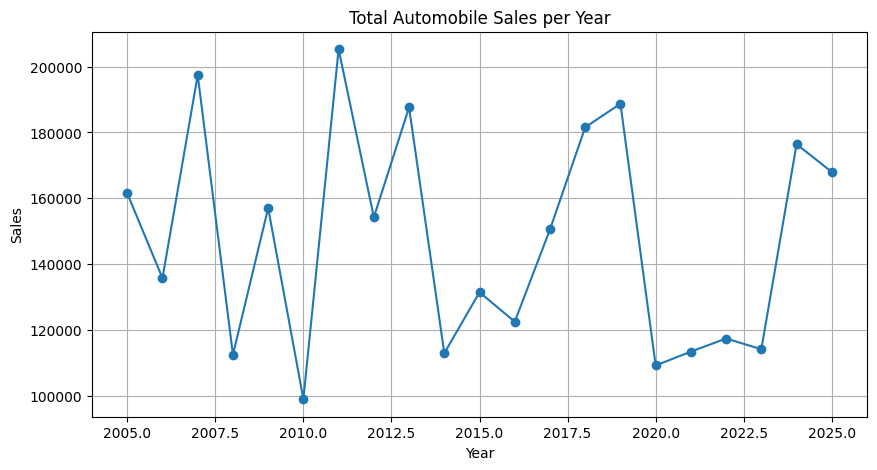

In [6]:

# Task 1.1: Line chart of total sales per year

plt.figure(figsize=(10,5))
yearly_sales = df.groupby('Year')['Sales'].sum()
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title("Total Automobile Sales per Year")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


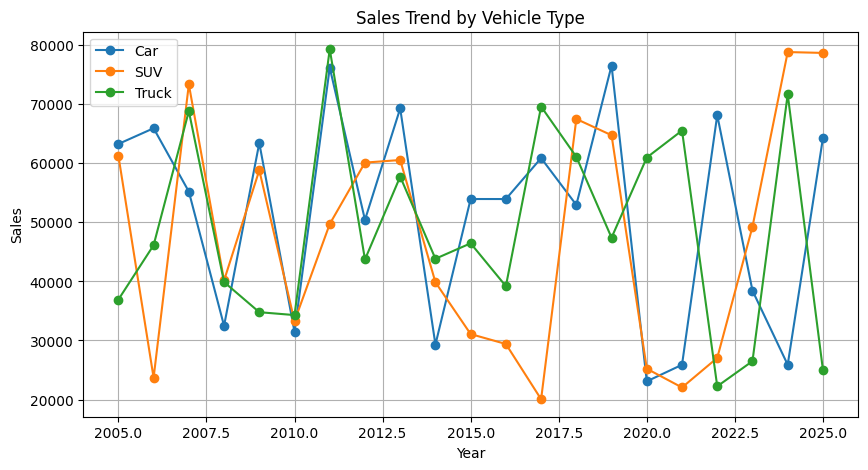

In [7]:

# Task 1.2: Line chart by Vehicle Type

plt.figure(figsize=(10,5))
for v_type in vehicle_types:
    temp = df[df['Vehicle_Type'] == v_type].groupby('Year')['Sales'].sum()
    plt.plot(temp.index, temp.values, marker='o', label=v_type)
plt.title("Sales Trend by Vehicle Type")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


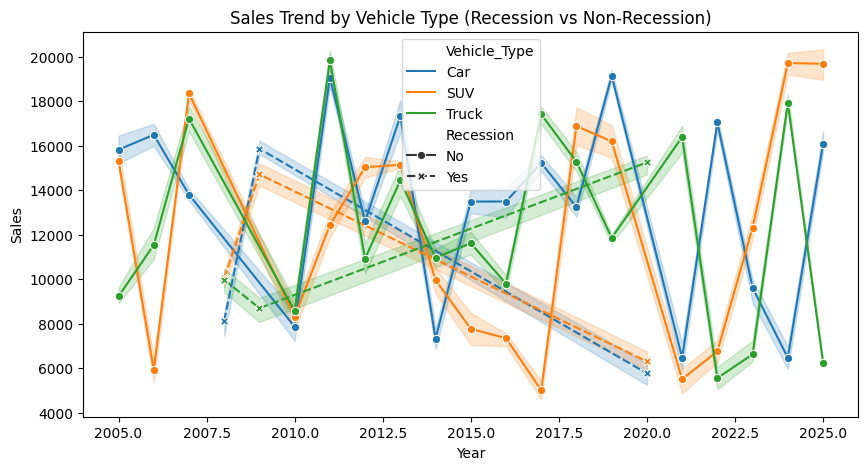

In [8]:
# Task 1.3: Seaborn line plot for Recession vs Non-Recession
plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='Year', y='Sales', hue='Vehicle_Type', style='Recession', markers=True)
plt.title("Sales Trend by Vehicle Type (Recession vs Non-Recession)")
plt.show()


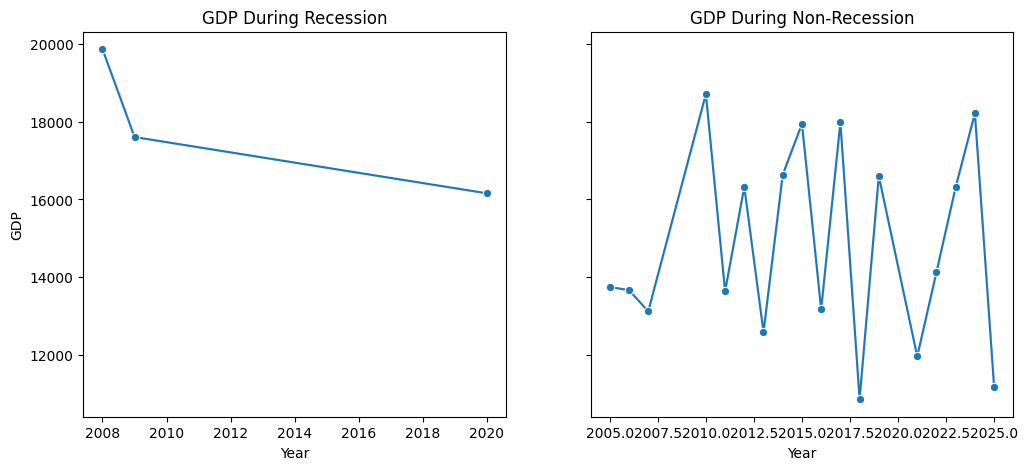

In [9]:
# Task 1.4: Subplots for GDP during Recession vs Non-Recession
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharey=True)
sns.lineplot(ax=axes[0], data=df[df['Recession']=='Yes'], x='Year', y='GDP', marker='o')
axes[0].set_title("GDP During Recession")
sns.lineplot(ax=axes[1], data=df[df['Recession']=='No'], x='Year', y='GDP', marker='o')
axes[1].set_title("GDP During Non-Recession")
plt.show()

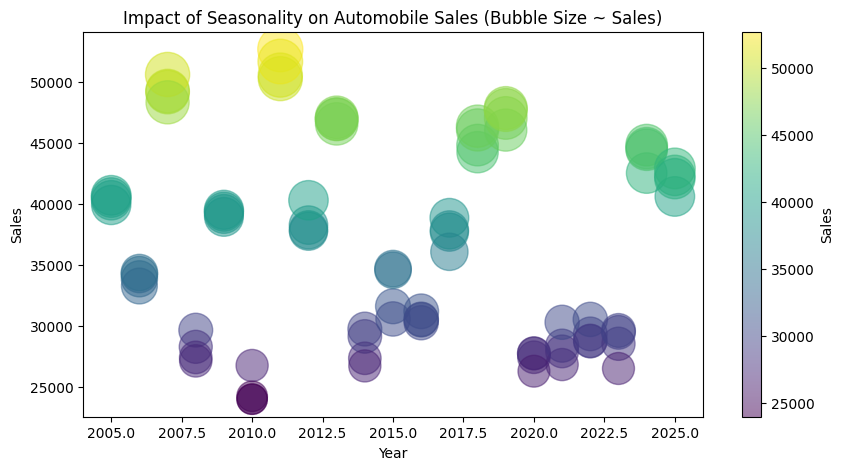

In [10]:
# Task 1.5: Bubble Plot for Seasonality impact
season_sales = df.groupby(['Year','Season'])['Sales'].sum().reset_index()
plt.figure(figsize=(10,5))
plt.scatter(season_sales['Year'], season_sales['Sales'], s=season_sales['Sales']/50, alpha=0.5, c=season_sales['Sales'], cmap='viridis')
plt.title("Impact of Seasonality on Automobile Sales (Bubble Size ~ Sales)")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.colorbar(label='Sales')
plt.show()

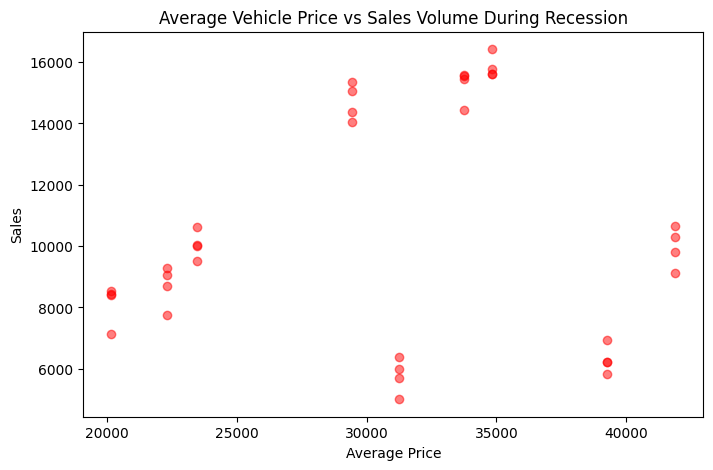

In [11]:
# Task 1.6: Scatter plot Avg Price vs Sales during Recession

recession_df = df[df['Recession']=='Yes']
plt.figure(figsize=(8,5))
plt.scatter(recession_df['Average_Price'], recession_df['Sales'], c='red', alpha=0.5)
plt.title("Average Vehicle Price vs Sales Volume During Recession")
plt.xlabel("Average Price")
plt.ylabel("Sales")
plt.show()


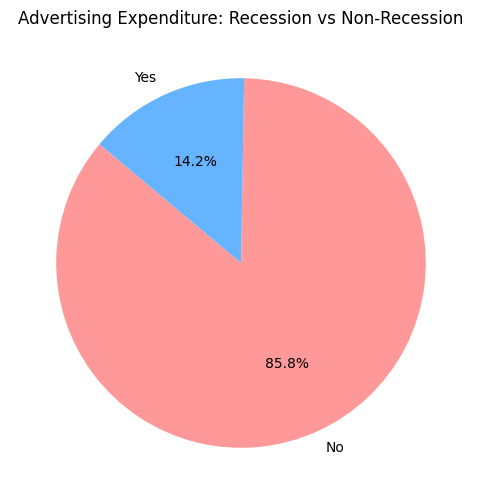

In [12]:
# Task 1.7: Pie chart for Advertising Expenditure (Recession vs Non-Recession)

ad_exp_totals = df.groupby('Recession')['Advertising_Expenditure'].sum()
plt.figure(figsize=(6,6))
plt.pie(ad_exp_totals, labels=ad_exp_totals.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title("Advertising Expenditure: Recession vs Non-Recession")
plt.show()

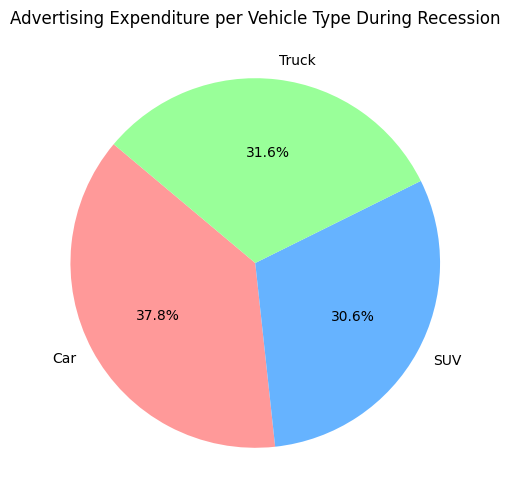

In [13]:
# Task 1.8: Pie chart for Ad Expenditure by Vehicle Type during Recession

ad_exp_vehicle = df[df['Recession']=='Yes'].groupby('Vehicle_Type')['Advertising_Expenditure'].sum()
plt.figure(figsize=(6,6))
plt.pie(ad_exp_vehicle, labels=ad_exp_vehicle.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title("Advertising Expenditure per Vehicle Type During Recession")
plt.show()


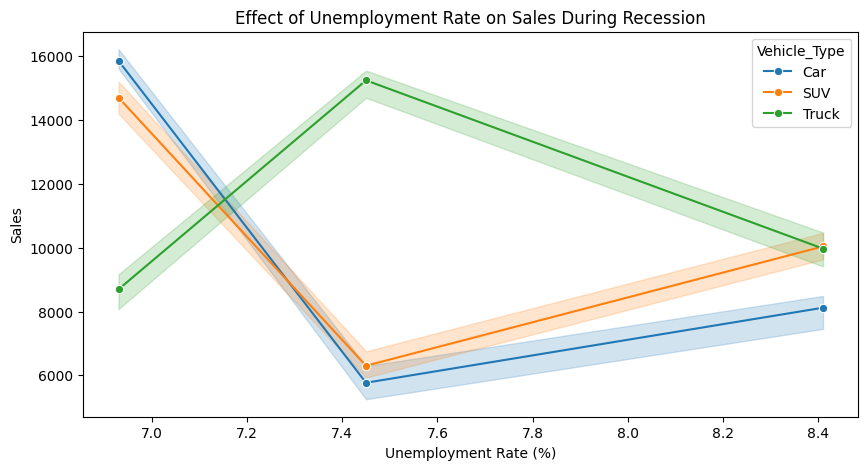

In [14]:
# Task 1.9: Line plot Unemployment Rate vs Sales by Vehicle Type during Recession

plt.figure(figsize=(10,5))
sns.lineplot(data=df[df['Recession']=='Yes'], x='Unemployment_Rate', y='Sales', hue='Vehicle_Type', marker='o')
plt.title("Effect of Unemployment Rate on Sales During Recession")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Sales")
plt.show()

# TASK 2 :
Let’s build the complete Dash app for Part 2 of your assignment. I’ll include:

App title

Dropdowns for filtering (Year, Vehicle Type, Recession)

Output display section

Callbacks to update graphs based on selections

Recession Report Statistics graphs

Yearly Report Statistics graphs

In [ ]:
# Import Libraries
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px


In [ ]:
# Step 1: Initialize Dash App
app = dash.Dash(__name__)
app.title = "Automobile Sales Dashboard"

In [ ]:
# Step 2: App Layout
app.layout = html.Div([
    html.H1("XYZ Automotives Sales Dashboard", style={'textAlign': 'center'}),

    # Dropdowns
    html.Div([
        html.Label("Select Vehicle Type:"),
        dcc.Dropdown(
            id='vehicle-dropdown',
            options=[{'label': v, 'value': v} for v in df['Vehicle_Type'].unique()],
            value='Car',
            clearable=False
        ),
        html.Label("Select Year:"),
        dcc.Dropdown(
            id='year-dropdown',
            options=[{'label': y, 'value': y} for y in df['Year'].unique()],
            value=2020,
            clearable=False
        ),
        html.Label("Select Recession Period:"),
        dcc.Dropdown(
            id='recession-dropdown',
            options=[{'label': r, 'value': r} for r in df['Recession'].unique()],
            value='Yes',
            clearable=False
        )
    ], style={'width':'30%', 'display':'inline-block', 'verticalAlign':'top', 'padding':20}),

    # Output Division for Graphs
    html.Div([
        dcc.Graph(id='recession-graph'),
        dcc.Graph(id='yearly-graph')
    ], style={'width':'65%', 'display':'inline-block', 'padding':20})
])